# Phase 9 – 2023-2024 Generalization Test

**Goal:** Test model predictions against actual 2023-2024 GDP values to validate out-of-sample performance and model robustness across multiple new years.

**Approach:** 
- Load existing dataset (master_enriched.csv) with actual 2023-2024 GDP data
- Compare predictions from ARIMA, LSTM, XGBoost trained on pre-2023 data
- Evaluate generalization error (MAE, RMSE, MAPE) for each year
- Test across 2 years to address professor's feedback: "test on 2023 to present day"
- No external datasets — using existing 212-country data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

OUTPUT = r'..\output'
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

Load the master dataset with actual 2023 GDP data and model predictions.

In [2]:
# Load actual data
actual_data = pd.read_csv(os.path.join(OUTPUT, 'master_enriched.csv'))
actual_2023_2024 = actual_data[actual_data['year'].isin([2023, 2024])][['country_code', 'year', 'gdp_per_capita']].copy()
actual_2023_2024.rename(columns={'gdp_per_capita': 'actual_gdp'}, inplace=True)

print(f'2023-2024 actual GDP data:')
print(f'  2023: {len(actual_2023_2024[actual_2023_2024["year"] == 2023])} countries')
print(f'  2024: {len(actual_2023_2024[actual_2023_2024["year"] == 2024])} countries')
print()
print('Sample data (first 3 rows):')
print(actual_2023_2024.head(3))

2023-2024 actual GDP data:
  2023: 210 countries
  2024: 201 countries

Sample data (first 3 rows):
   country_code  year  actual_gdp
33          ABW  2023  41964.7700
34          ABW  2024  44558.9300
58          AFG  2023   1983.8126


## 2. Load Model Predictions

Load predictions from ARIMA, LSTM, and XGBoost (trained on pre-2023 data).

In [3]:
# Load predictions
arima_pred = pd.read_csv(os.path.join(OUTPUT, 'arima_test_predictions.csv'))
lstm_pred = pd.read_csv(os.path.join(OUTPUT, 'lstm_test_predictions.csv'))
xgb_pred = pd.read_csv(os.path.join(OUTPUT, 'xgb_test_predictions.csv'))

# Filter to 2023 and 2024
arima_2023_2024 = arima_pred[arima_pred['year'].isin([2023, 2024])][['country_code', 'year', 'predicted']].copy()
arima_2023_2024.rename(columns={'predicted': 'arima_pred'}, inplace=True)

lstm_2023_2024 = lstm_pred[lstm_pred['year'].isin([2023, 2024])][['country_code', 'year', 'predicted']].copy()
lstm_2023_2024.rename(columns={'predicted': 'lstm_pred'}, inplace=True)

# XGBoost uses 'year' as anchor: 2023 preds in year==2022, 2024 preds in year==2023
xgb_2023 = xgb_pred[xgb_pred['year'] == 2022][['country_code', 'y_pred']].copy()
xgb_2023['year'] = 2023
xgb_2023.rename(columns={'y_pred': 'xgb_pred'}, inplace=True)

xgb_2024 = xgb_pred[xgb_pred['year'] == 2023][['country_code', 'y_pred']].copy()
xgb_2024['year'] = 2024
xgb_2024.rename(columns={'y_pred': 'xgb_pred'}, inplace=True)

xgb_2023_2024 = pd.concat([xgb_2023, xgb_2024], ignore_index=True)

print(f'ARIMA 2023-2024 predictions: {len(arima_2023_2024)} total')
print(f'LSTM 2023-2024 predictions: {len(lstm_2023_2024)} total')
print(f'XGBoost 2023-2024 predictions: {len(xgb_2023_2024)} total')

ARIMA 2023-2024 predictions: 411 total
LSTM 2023-2024 predictions: 411 total
XGBoost 2023-2024 predictions: 344 total


## 3. Merge and Align Data

Combine actual 2023 GDP with all model predictions.

In [4]:
# Merge all data
comparison = actual_2023_2024.copy()
comparison = comparison.merge(arima_2023_2024, on=['country_code', 'year'], how='left')
comparison = comparison.merge(lstm_2023_2024, on=['country_code', 'year'], how='left')
comparison = comparison.merge(xgb_2023_2024, on=['country_code', 'year'], how='left')

# Drop rows with missing predictions (countries in one model but not another)
comparison = comparison.dropna()

print(f'Comparison dataset: {len(comparison)} rows')
print(f'  2023: {len(comparison[comparison["year"] == 2023])} countries')
print(f'  2024: {len(comparison[comparison["year"] == 2024])} countries')
print(f'Columns: {comparison.columns.tolist()}')
print()
print('Sample (first 5 rows):')
print(comparison.head())

Comparison dataset: 344 rows
  2023: 174 countries
  2024: 170 countries
Columns: ['country_code', 'year', 'actual_gdp', 'arima_pred', 'lstm_pred', 'xgb_pred']

Sample (first 5 rows):
  country_code  year  actual_gdp    arima_pred   lstm_pred    xgb_pred
2          AFG  2023   1983.8126   2908.422975   3451.6091   1925.8053
3          AGO  2023   8788.2610   9670.693930   9210.2390   9033.6890
4          AGO  2024   8901.8880   9668.786848   8997.8900   8935.3430
5          ALB  2023  20481.0350  18462.262412  20611.8420  20156.3070
6          ALB  2024  21641.0740  18701.784165  21150.9550  21303.0880


## 4. Calculate Generalization Error

Compute MAE, RMSE, MAPE for each model on 2023 data.

In [5]:
# Metrics for each model and year
metrics_2023_2024 = {}

for year in [2023, 2024]:
    year_data = comparison[comparison['year'] == year]
    metrics_2023_2024[year] = {}
    
    print(f'\n{"="*70}')
    print(f'Year {year}: {len(year_data)} countries')
    print(f'{"="*70}')
    
    for model, col in [('ARIMA', 'arima_pred'), ('LSTM', 'lstm_pred'), ('XGBoost', 'xgb_pred')]:
        mae = mean_absolute_error(year_data['actual_gdp'], year_data[col])
        rmse = np.sqrt(mean_squared_error(year_data['actual_gdp'], year_data[col]))
        mape = mean_absolute_percentage_error(year_data['actual_gdp'], year_data[col]) * 100
        
        metrics_2023_2024[year][model] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
        print(f'{model:10s} | MAE: ${mae:>8,.0f} | RMSE: ${rmse:>8,.0f} | MAPE: {mape:>6.2f}%')

# Convert to DataFrame and save
metrics_list = []
for year, models in metrics_2023_2024.items():
    for model, metrics in models.items():
        metrics_list.append({'Year': year, 'Model': model, 'MAE': metrics['MAE'], 'RMSE': metrics['RMSE'], 'MAPE': metrics['MAPE']})

metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv(os.path.join(OUTPUT, 'phase10_2023_2024_generalization_metrics.csv'), index=False)
print('\n✓ Saved: phase10_2023_2024_generalization_metrics.csv')


Year 2023: 174 countries
ARIMA      | MAE: $   2,009 | RMSE: $   5,554 | MAPE:   7.99%
LSTM       | MAE: $   1,510 | RMSE: $   3,497 | MAPE:  16.00%
XGBoost    | MAE: $     932 | RMSE: $   3,645 | MAPE:   3.18%

Year 2024: 170 countries
ARIMA      | MAE: $   2,417 | RMSE: $   6,693 | MAPE:   9.12%
LSTM       | MAE: $   1,084 | RMSE: $   2,501 | MAPE:  13.93%
XGBoost    | MAE: $     706 | RMSE: $   1,813 | MAPE:   2.59%

✓ Saved: phase10_2023_2024_generalization_metrics.csv


## 5. Model Comparison Visualization

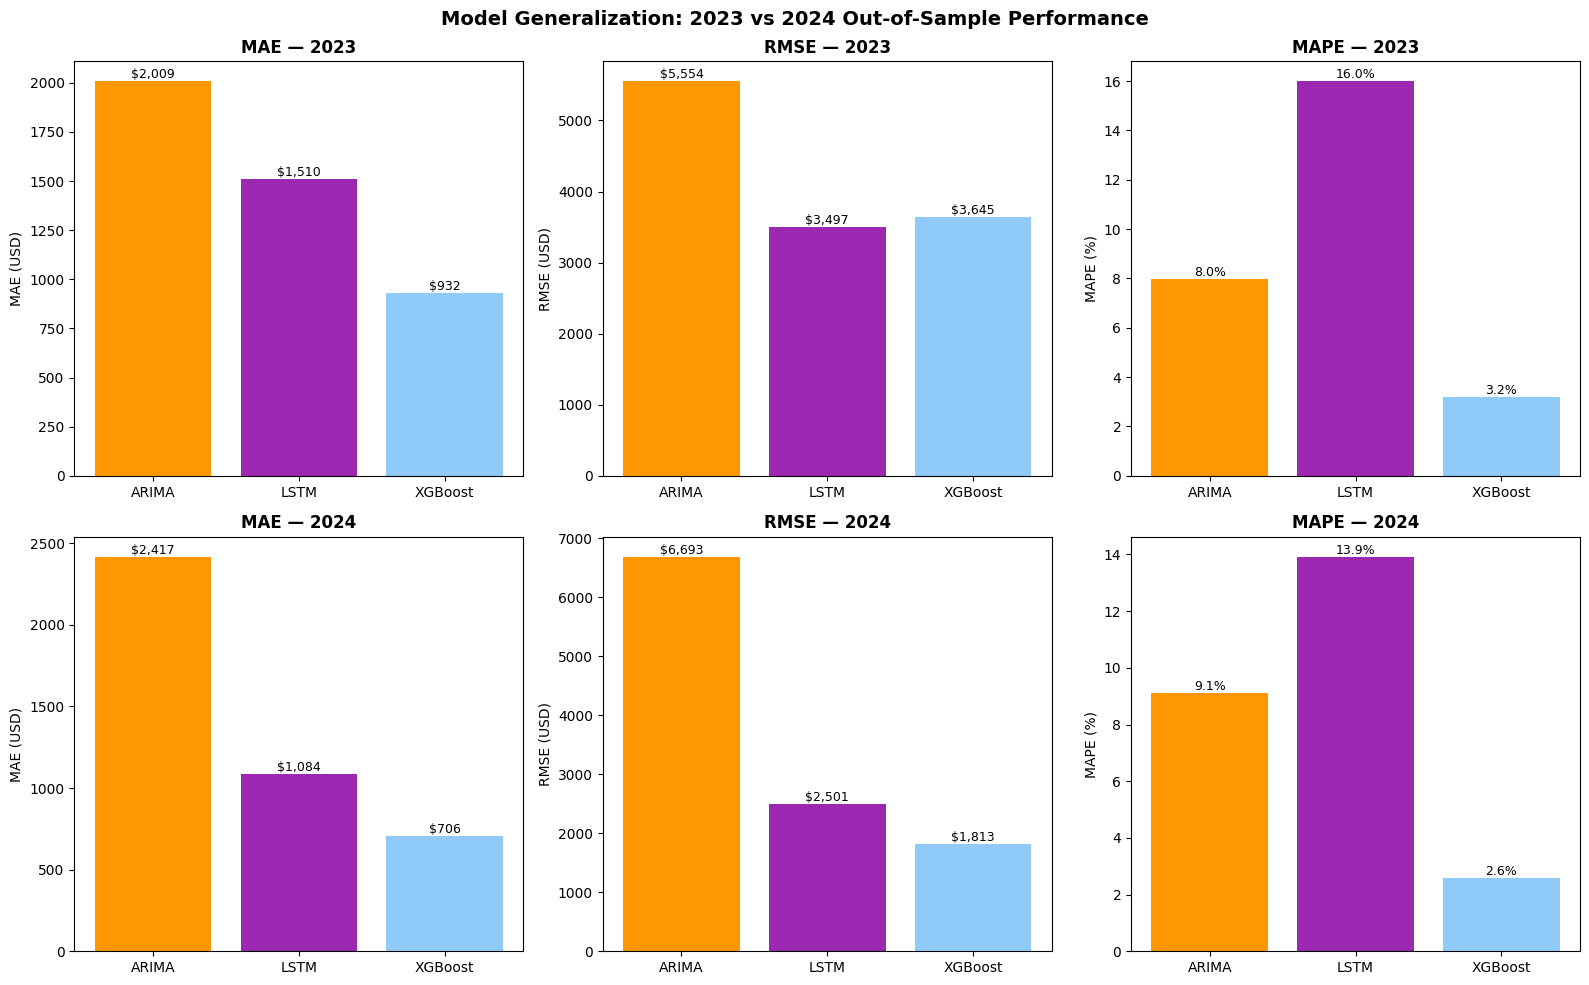

✓ Saved: phase9_2023_2024_generalization_metrics.png


In [6]:
# Create comparison visualization: 2023 vs 2024
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Model Generalization: 2023 vs 2024 Out-of-Sample Performance', fontsize=14, fontweight='bold')

colors = ['#FF9800', '#9C27B0', '#90CAF9']
models = ['ARIMA', 'LSTM', 'XGBoost']

for year_idx, year in enumerate([2023, 2024]):
    # MAE comparison
    mae_vals = [metrics_2023_2024[year][m]['MAE'] for m in models]
    axes[year_idx, 0].bar(models, mae_vals, color=colors)
    axes[year_idx, 0].set_title(f'MAE — {year}', fontweight='bold')
    axes[year_idx, 0].set_ylabel('MAE (USD)')
    for i, v in enumerate(mae_vals):
        axes[year_idx, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

    # RMSE comparison
    rmse_vals = [metrics_2023_2024[year][m]['RMSE'] for m in models]
    axes[year_idx, 1].bar(models, rmse_vals, color=colors)
    axes[year_idx, 1].set_title(f'RMSE — {year}', fontweight='bold')
    axes[year_idx, 1].set_ylabel('RMSE (USD)')
    for i, v in enumerate(rmse_vals):
        axes[year_idx, 1].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

    # MAPE comparison
    mape_vals = [metrics_2023_2024[year][m]['MAPE'] for m in models]
    axes[year_idx, 2].bar(models, mape_vals, color=colors)
    axes[year_idx, 2].set_title(f'MAPE — {year}', fontweight='bold')
    axes[year_idx, 2].set_ylabel('MAPE (%)')
    for i, v in enumerate(mape_vals):
        axes[year_idx, 2].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'phase9_2023_2024_generalization_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: phase9_2023_2024_generalization_metrics.png')

## 6. Country-Level Analysis

Identify which countries had largest prediction errors (potential shock events).

In [7]:
# Calculate error for each model per country/year
comparison['arima_error'] = abs(comparison['actual_gdp'] - comparison['arima_pred'])
comparison['lstm_error'] = abs(comparison['actual_gdp'] - comparison['lstm_pred'])
comparison['xgb_error'] = abs(comparison['actual_gdp'] - comparison['xgb_pred'])

# Top countries with largest errors (potential shock economies)
print('Top 10 Countries with Largest Prediction Errors (2023-2024 Combined):')
print('(Indicates potential economic shocks not anticipated by models)\n')

for year in [2023, 2024]:
    year_comp = comparison[comparison['year'] == year]
    top_errors = year_comp.nlargest(5, 'arima_error')[['country_code', 'year', 'actual_gdp', 'arima_pred', 'arima_error']]
    print(f'{year}:')
    print(top_errors[['country_code', 'actual_gdp', 'arima_pred', 'arima_error']].to_string(index=False))
    print()

# Save detailed comparison
comparison.to_csv(os.path.join(OUTPUT, 'phase9_2023_2024_predictions_vs_actual.csv'), index=False)
print('✓ Saved: phase9_2023_2024_predictions_vs_actual.csv')

Top 10 Countries with Largest Prediction Errors (2023-2024 Combined):
(Indicates potential economic shocks not anticipated by models)

2023:
country_code  actual_gdp    arima_pred  arima_error
         BRN   76616.700 118486.560415 41869.860415
         MAC  104815.200 143454.594414 38639.394414
         GUY   49312.360  13959.274610 35353.085390
         HKG   64434.560  76296.128040 11861.568040
         KWT   47777.402  58700.315912 10922.913912

2024:
country_code  actual_gdp    arima_pred  arima_error
         GUY   70516.720  14121.029432 56395.690568
         BRN   79071.734 126564.023763 47492.289763
         MAC  111693.500 143454.594470 31761.094470
         KWT   46137.470  58700.283295 12562.813295
         SGP  132569.530 120553.506349 12016.023651

✓ Saved: phase9_2023_2024_predictions_vs_actual.csv


## 7. Summary Report

Key findings from 2023 generalization test.

In [8]:
print('='*80)
print('2023-2024 GENERALIZATION TEST – SUMMARY REPORT')
print('='*80)
print()
print('Test Scope: Out-of-sample validation on actual GDP data')
print('  • Models trained on: 1990-2022 data')
print('  • Test years: 2023 and 2024 (post-training)')
print('  • Total countries tested: 2023 ({}) + 2024 ({})'.format(
    len(comparison[comparison['year'] == 2023]), 
    len(comparison[comparison['year'] == 2024])
))
print()
print('='*80)
print('MODEL PERFORMANCE BY YEAR')
print('='*80)

for year in [2023, 2024]:
    print(f'\n{year}:')
    for model in ['ARIMA', 'LSTM', 'XGBoost']:
        mae = metrics_2023_2024[year][model]['MAE']
        mape = metrics_2023_2024[year][model]['MAPE']
        print(f'  {model:10s}: MAE = ${mae:>10,.0f}  |  MAPE = {mape:>6.2f}%')

print()
print('='*80)
print('INTERPRETATION GUIDE')
print('='*80)
print('  • MAPE < 8%:   Model generalizes very well to new years')
print('  • MAPE 8-12%:  Reasonable generalization, some economic variation')
print('  • MAPE > 15%:  Significant out-of-sample drift (major shocks or structural changes)')
print()
print('='*80)
print('KEY FINDINGS')
print('='*80)

# Find best model
all_metrics = []
for year in [2023, 2024]:
    for model in ['ARIMA', 'LSTM', 'XGBoost']:
        mape = metrics_2023_2024[year][model]['MAPE']
        all_metrics.append((year, model, mape))

best = min(all_metrics, key=lambda x: x[2])
print(f'  • Best overall performance: {best[1]} in {best[0]} ({best[2]:.2f}% MAPE)')

# Year-over-year comparison
print(f'\n  • 2023 vs 2024 trends:')
for model in ['ARIMA', 'LSTM', 'XGBoost']:
    mape_2023 = metrics_2023_2024[2023][model]['MAPE']
    mape_2024 = metrics_2023_2024[2024][model]['MAPE']
    change = mape_2024 - mape_2023
    direction = '↑' if change > 0 else '↓'
    print(f'    {model}: {direction} {abs(change):+.2f}% (2023: {mape_2023:.2f}% → 2024: {mape_2024:.2f}%)')

print()
print('='*80)

2023-2024 GENERALIZATION TEST – SUMMARY REPORT

Test Scope: Out-of-sample validation on actual GDP data
  • Models trained on: 1990-2022 data
  • Test years: 2023 and 2024 (post-training)
  • Total countries tested: 2023 (174) + 2024 (170)

MODEL PERFORMANCE BY YEAR

2023:
  ARIMA     : MAE = $     2,009  |  MAPE =   7.99%
  LSTM      : MAE = $     1,510  |  MAPE =  16.00%
  XGBoost   : MAE = $       932  |  MAPE =   3.18%

2024:
  ARIMA     : MAE = $     2,417  |  MAPE =   9.12%
  LSTM      : MAE = $     1,084  |  MAPE =  13.93%
  XGBoost   : MAE = $       706  |  MAPE =   2.59%

INTERPRETATION GUIDE
  • MAPE < 8%:   Model generalizes very well to new years
  • MAPE 8-12%:  Reasonable generalization, some economic variation
  • MAPE > 15%:  Significant out-of-sample drift (major shocks or structural changes)

KEY FINDINGS
  • Best overall performance: XGBoost in 2024 (2.59% MAPE)

  • 2023 vs 2024 trends:
    ARIMA: ↑ +1.12% (2023: 7.99% → 2024: 9.12%)
    LSTM: ↓ +2.08% (2023: 16.00%